Analyze the scans preprocessing - how many scans were disqualified, why, manual classification and source 
The goal - identify scans we can try to save by looking for more data (Yaniv) or use algorithms to smooth (Gaia)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
final_labeled_scans = pd.read_csv("/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/manual_labels_resolved_duplicates.csv")

combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')

# remove duplicates based on subject_id and session_id
combined_df_scans = combined_df.drop_duplicates(subset=['subject_id', 'session_id'])

combined_df_scans['source'] = combined_df_scans['source'].astype(str)

/tmp/ipykernel_280250/1843300100.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_scans['source'] = combined_df_scans['source'].astype(str)


In [3]:
# 1 = Good, = color code = green
# 2 = pixeled (cubes in the scan) = color code = orange
# 3 = striped (slices too big) = color code = orange 
# 4 = black jpg, 
# 5 = not usable scan (partial brain) = color code = red

# 1. Define descriptive names and the specific color mapping
# We use strings because after renaming columns, the labels will be text
label_names = {
    1.0: '1: Good',
    2.0: '2: Pixeled',
    3.0: '3: Striped',
    4.0: '4: Black JPG',
    5.0: '5: Not Usable',
    'Missing': 'Missing'
}

# Map the descriptive names to your colors
# Note: 2 and 3 both map to orange as requested
color_map = {
    '1: Good': 'green',
    '2: Pixeled': 'orange',
    '3: Striped': 'orange',
    '4: Black JPG': 'black',
    '5: Not Usable': 'red',
    'Missing': 'gray' # Adding a neutral color for NaNs
}

In [36]:
list_for_yaniv_pixeled = final_labeled_scans[final_labeled_scans['classification_label'].isin([2, 3])]['session_id']
list_for_yaniv_partial_scans = final_labeled_scans[final_labeled_scans['classification_label'] == 5]['session_id']

list_for_yaniv_pixeled.to_csv("/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/list_for_yaniv_pixeled.csv", index=False)
list_for_yaniv_partial_scans.to_csv("/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/list_for_yaniv_partial_scans.csv", index=False)

### comparison between the manually-labeled scans and combined_df

In [4]:
# preperations for comparison 

# # remove 'file_path' column from labeled_scans 
# final_labeled_scans = final_labeled_scans[['subject_id', 'session_id', 'classification_label']]

# remove "sub-" prefix from subject_id and "ses-" prefix from session_id
final_labeled_scans['subject_id'] = final_labeled_scans['subject_id'].str.replace('sub-', '', regex=False)
final_labeled_scans['session_id'] = final_labeled_scans['session_id'].str.replace('ses-', '', regex=False)

# add comparison key (subject_id + session_id combination)
final_labeled_scans['key'] = final_labeled_scans['subject_id'].astype(str) + '_' + final_labeled_scans['session_id'].astype(str)
combined_df_scans['key'] = combined_df_scans['subject_id'].astype(str) + '_' + combined_df_scans['session_id'].astype(str)


/tmp/ipykernel_280250/1356158158.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_scans['key'] = combined_df_scans['subject_id'].astype(str) + '_' + combined_df_scans['session_id'].astype(str)


In [ ]:
might_improve = final_labeled_scans[final_labeled_scans['classification_label'].isin([2, 3])]
metadata_of_might_improve = combined_df_scans[combined_df_scans['key'].isin(might_improve['key'])]

#

In [5]:
# in manual label, not in combined_df
missing_scans = final_labeled_scans[~final_labeled_scans['key'].isin(combined_df_scans['key'])]
missing_scans = missing_scans.drop_duplicates(subset=['key'])
print(f"Number of scans that were manually labeled but not in combined_df: {len(missing_scans)}")

Number of scans that were manually labeled but not in combined_df: 87


In [6]:
# in combined_df, not labeled and not snbb
unlabeled_scans = combined_df_scans[~combined_df_scans['key'].isin(final_labeled_scans['key'])]
unlabeled_scans = unlabeled_scans[unlabeled_scans['source'] != 'snbb']
unlabeled_scans = unlabeled_scans.drop_duplicates(subset=['key'])
print(f"Number of scans in combined df that are not source==snbb and were NOT manually labeled: {len(unlabeled_scans)}")

Number of scans in combined df that are not source==snbb and were NOT manually labeled: 2


In [7]:
# separate snbb from the rest
snbb_scans = combined_df_scans[combined_df_scans['source'] == 'snbb']
old_scans = combined_df_scans[combined_df_scans['source'] != 'snbb']

In [8]:
print("Based on combined_df:")
print(f"amount of scans from snbb source: {snbb_scans.shape[0]}")
print(f"diqualified old scans because sesison_id is nan: {old_scans[old_scans['session_id']=='nan'].shape[0]}")
print(f"amount of good old scans: {old_scans[old_scans['session_id']!='nan'].shape[0]}")
print(f"total old scans: {old_scans.shape[0]}")

Based on combined_df:
amount of scans from snbb source: 3817
diqualified old scans because sesison_id is nan: 0
amount of good old scans: 1025
total old scans: 1025


In [9]:
# compare old_scans['key'] to final_labeled_scans['key']
keys_in_old_scans = set(old_scans['key'].unique())
keys_in_labeled_scans = set(final_labeled_scans['key'].unique())
keys_not_in_labeled_scans = keys_in_old_scans - keys_in_labeled_scans

print(f"size of keys in old_scans: {len(keys_in_old_scans)}")
print(f"size of keys in labeled_scans: {len(keys_in_labeled_scans)}")
print(f"size of keys not in labeled scans: {len(keys_not_in_labeled_scans)}")



size of keys in old_scans: 1025
size of keys in labeled_scans: 1110
size of keys not in labeled scans: 2


In [10]:
# Keys that are in Labeled but NOT in Old (The "Extra" 87 keys)
keys_only_in_labeled = keys_in_labeled_scans - keys_in_old_scans

# Keys that are in both (The "Intersection")
common_keys = keys_in_old_scans.intersection(keys_in_labeled_scans)

# Keys that are in one OR the other, but not both (Symmetric Difference)
all_differences = keys_in_old_scans ^ keys_in_labeled_scans

print(f"Keys only in Labeled: {len(keys_only_in_labeled)}") # Likely 87
print(f"Common keys: {len(common_keys)}")                 # Likely 1023

Keys only in Labeled: 87
Common keys: 1023


In [11]:
# print a list of keys in keys_only_in_labeled
print("Keys only in labeled:")
for key in sorted(keys_only_in_labeled):
    print(key)

Keys only in labeled:
ls001_20031125
ls001_20040101
ls001_20040229
ls009_20070328
ls013_20070221
ls041_20090602
ls042_20050317
ls042_20050420
ls047_20111217
ls049_20120128
ls060_20070830
ls061_20061227
ls072_20060526
ls074_20060504
ls075_20060517
ls082_20051112
ls082_20051223
ls089_20060119
ls091_20060202
ls092_20060212
ls095_20060222
ls095_20070208
ls098_20060618
ls100_20060306
ls102_20070206
ls103_20060315
ls104_20060315
ls104_20070102
ls105_20060319
ls105_20060519
ls106_20050922
ls106_20060329
ls107_20051223
ls108_20060109
ls108_20060221
ls109_20060202
ls109_20060430
ls112_20070107
ls147_20080913
ls147_20111022
ls154_20070325
ls156_20060919
ls160_20031104
ls160_20031130
ls160_20040229
ls162_20070112
ls164_20051205
ls164_20060115
ls164_20061129
ls164_20070322
ls164_20070723
ls164_20080409
ls167_20080222
ls168_20071024
ls169_20070627
ls176_20050102
ls177_20060307
ls181_20050203
ls181_20070418
ls184_20050210
ls190_20051222
ls191_20061023
ls191_20070118
ls191_20070712
ls191_20080121
ls1

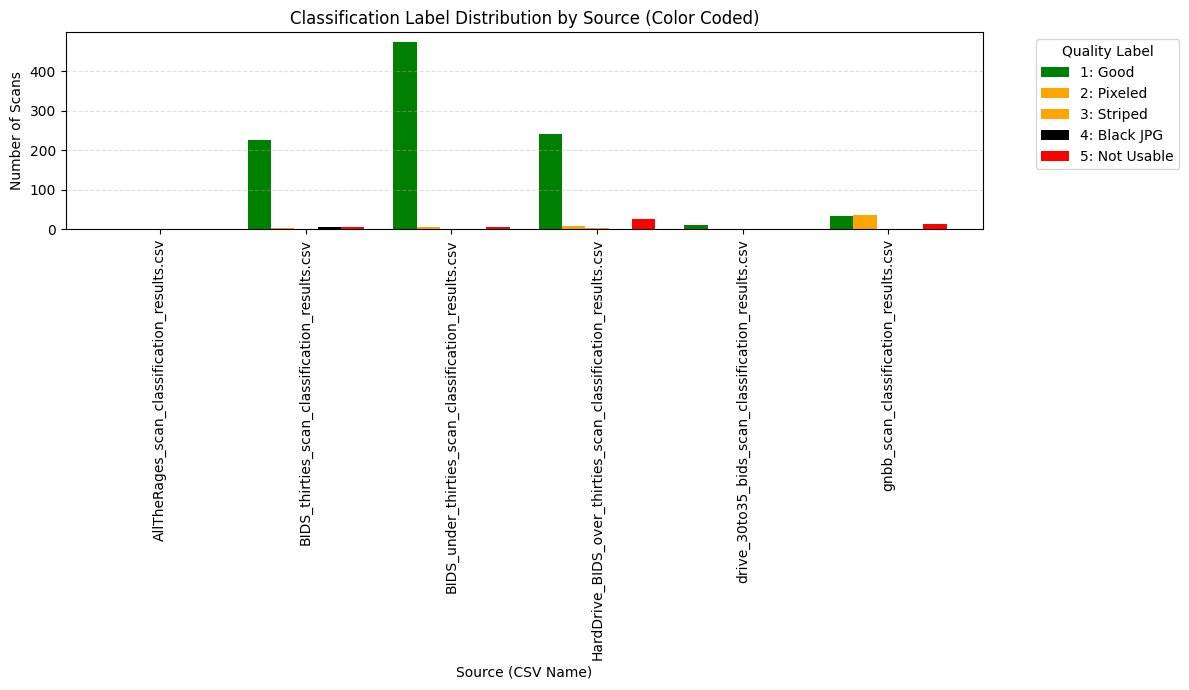

In [12]:
# 2. Create the counts including NaNs
counts_df = (
    final_labeled_scans.groupby('csv_name')['classification_label']
    .value_counts(dropna=False)
    .unstack(fill_value=0)
)

# 3. Rename columns to descriptive strings
# This handles both the numeric labels and the various forms of NaN
counts_df = counts_df.rename(columns={
    pd.NA: 'Missing', 
    float('nan'): 'Missing',
    None: 'Missing'
})
counts_df = counts_df.rename(columns=label_names)

# 4. Ensure the columns are plotted in a specific order if they exist
# This prevents the colors from shifting if a source is missing a specific label
plot_order = [label for label in label_names.values() if label in counts_df.columns]
final_colors = [color_map[label] for label in plot_order]

# 5. Plot
ax = counts_df[plot_order].plot(
    kind='bar', 
    figsize=(12, 7), 
    width=0.8, 
    color=final_colors
)

plt.title('Classification Label Distribution by Source (Color Coded)')
plt.xlabel('Source (CSV Name)')
plt.ylabel('Number of Scans')
plt.legend(title='Quality Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

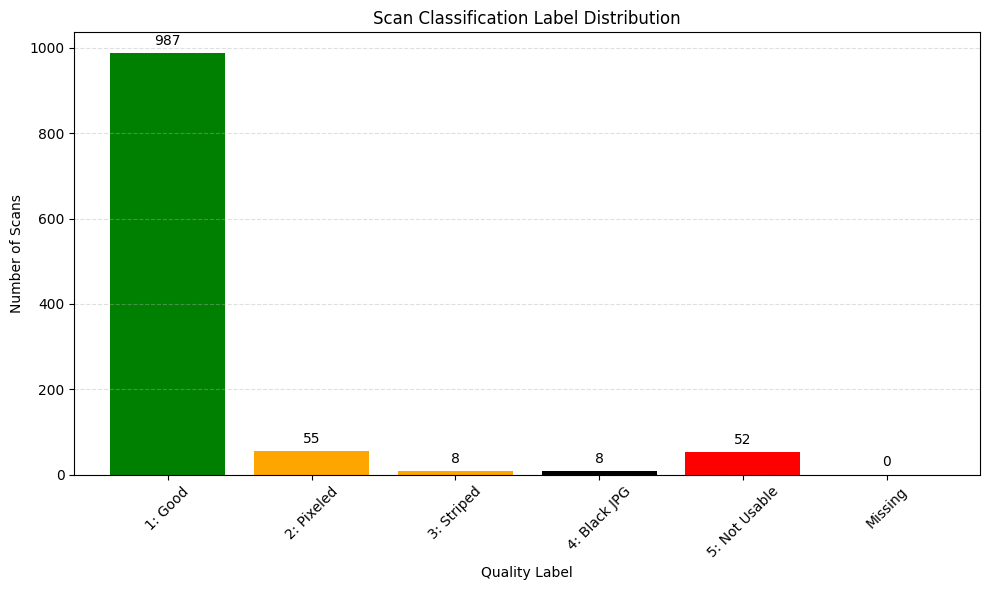

In [13]:
# 2. Calculate counts and handle NaNs
counts_series = final_labeled_scans['classification_label'].value_counts(dropna=False)

# Rename the index using the descriptive labels
# We handle the various NaN types first, then map the numbers to names
counts_series.index = [label_names.get(i, 'Missing') if pd.notna(i) else 'Missing' for i in counts_series.index]

# 3. Reorder to ensure they appear in 1, 2, 3... order
# This ensures the chart is logical even if some categories are small
order = ['1: Good', '2: Pixeled', '3: Striped', '4: Black JPG', '5: Not Usable', 'Missing']
counts_series = counts_series.reindex(order).fillna(0)

# 4. Map the colors to the specific labels present in our series
colors = [color_map[label] for label in counts_series.index]

# 5. Plot
plt.figure(figsize=(10, 6))
ax = counts_series.plot(kind='bar', width=0.8, color=colors)

plt.title('Scan Classification Label Distribution')
plt.xlabel('Quality Label')
plt.ylabel('Number of Scans')
plt.xticks(rotation=45) # Reduced rotation for better readability of descriptions
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Optional: Add text labels on top of bars for 3M row datasets
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

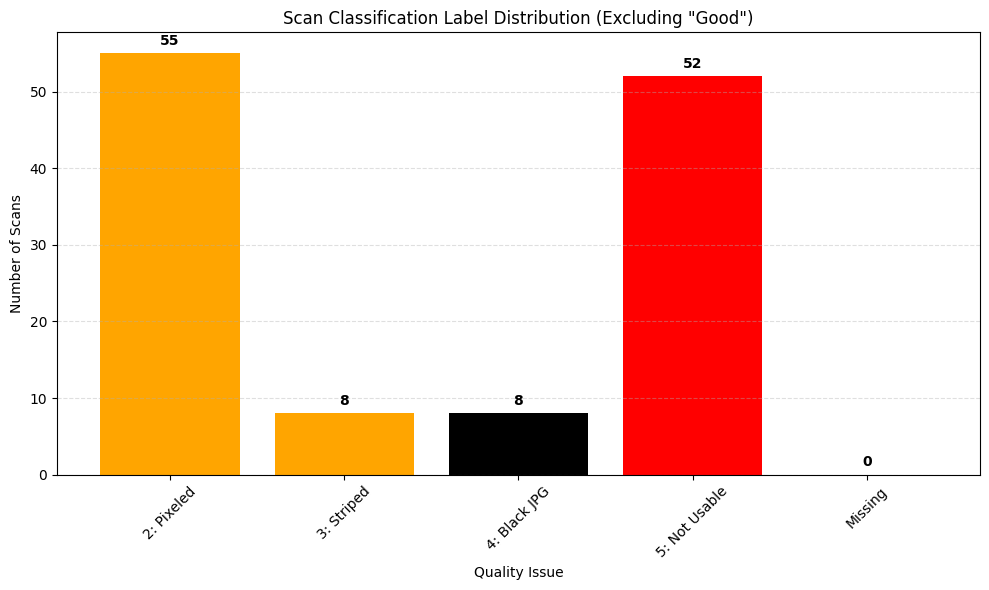

In [ ]:
# 2. Filter out the "Good" labels (1) and calculate counts
# We focus only on the issues and missing values
no_good_scans = final_labeled_scans[final_labeled_scans['classification_label'] != 1]
counts_series = no_good_scans['classification_label'].value_counts(dropna=False)

good_scans = final_labeled_scans[final_labeled_scans['classification_label'] == 1]

# 3. Rename the index to descriptive names
counts_series.index = [label_names.get(i, 'Missing') if pd.notna(i) else 'Missing' for i in counts_series.index]

# 4. Reindex to ensure a logical order (2, 3, 4, 5, Missing)
order = ['2: Pixeled', '3: Striped', '4: Black JPG', '5: Not Usable', 'Missing']
counts_series = counts_series.reindex(order).fillna(0)

# 5. Map the colors to the labels present in the filtered series
colors = [color_map[label] for label in counts_series.index]

# 6. Plot
plt.figure(figsize=(10, 6))
ax = counts_series.plot(kind='bar', width=0.8, color=colors)

plt.title('Scan Classification Label Distribution (Excluding "Good")')
plt.xlabel('Quality Issue')
plt.ylabel('Number of Scans')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Add text labels on top of bars so you can see exact numbers for the 3M row dataset
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontweight='bold')

plt.tight_layout()
plt.show()

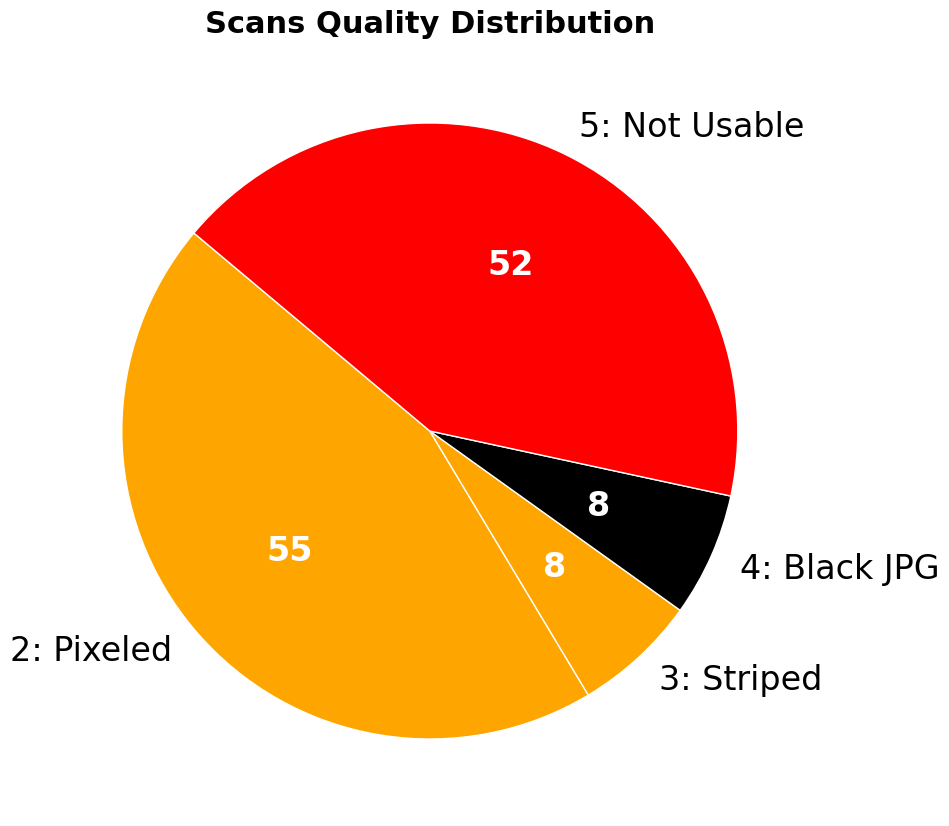

In [21]:
# 1. Group the data
no_good_scans_by_label = no_good_scans.groupby('classification_label').size()

# 2. Map the indices to names and colors
mapped_labels = [label_names.get(x, str(x)) for x in no_good_scans_by_label.index]
pie_colors = [color_map.get(name, 'gray') for name in mapped_labels]

# 3. Define the count formatter
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{v:d}'.format(v=val)
    return my_autopct

# 4. Plot
plt.figure(figsize=(10, 10)) # Increased figure size slightly to accommodate larger text

# Use textprops to set the size of the outer labels
patches, texts, autotexts = plt.pie(
    no_good_scans_by_label.values, 
    labels=mapped_labels, 
    autopct=make_autopct(no_good_scans_by_label.values),
    colors=pie_colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 24} # <--- Sets the size for the outer labels
)

# 5. Format the internal numbers (Autotexts)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')
    autotext.set_size(24) # <--- Sets the size for the numbers inside the pie

# 6. Format the Title
plt.title('Scans Quality Distribution', fontsize=22, pad=10, fontweight='bold')

plt.show()

# analyze the bad scan by their subject

In [ ]:
subjects_with_label_1 = set(good_scans['subject_id'].unique())
subjects_with_other_labels = set(no_good_scans['subject_id'].unique())
print(f"Subjects with label 1: {len(subjects_with_label_1)}")
print(f"Subjects with scans labeled != 1: {len(subjects_with_other_labels)}")

# are subjects_with_other_labels also are it sibjects_with_label?
subjects_in_both = subjects_with_label_1.intersection(subjects_with_other_labels)
print(f"there are {len(subjects_in_both)} subjects in both sets")

# subjects only in _subjects_with_other labels and what labels
subjects_only_in_other = subjects_with_other_labels - subjects_with_label_1
print(f"there are {len(subjects_only_in_other)} subjects with bad scans only")

# get the labels for these subjects
other_labels_scans = no_good_scans[no_good_scans['subject_id'].isin(subjects_only_in_other)]
print(other_labels_scans[['subject_id', 'classification_label']].drop_duplicates())

Subjects with label 1: 866
Subjects with scans labeled != 1: 93
there are 56 subjects in both sets
there are 37 subjects with bad scans only
     subject_id  classification_label
62        ls167                     5
63        ls168                     4
73        ls211                     2
139       ls443                     5
140       ls446                     5
253       ls011                     2
282       ls064                     5
299       ls089                     5
306      ls1001                     4
339       ls130                     2
353       ls174                     5
355       ls177                     5
357       ls181                     5
372       ls199                     5
375       ls202                     5
387       ls302                     5
390       ls317                     5
392       ls330                     5
393       ls335                     5
394       ls342                     5
395       ls343                     5
396       ls367        

# analyze the bad scan by scan

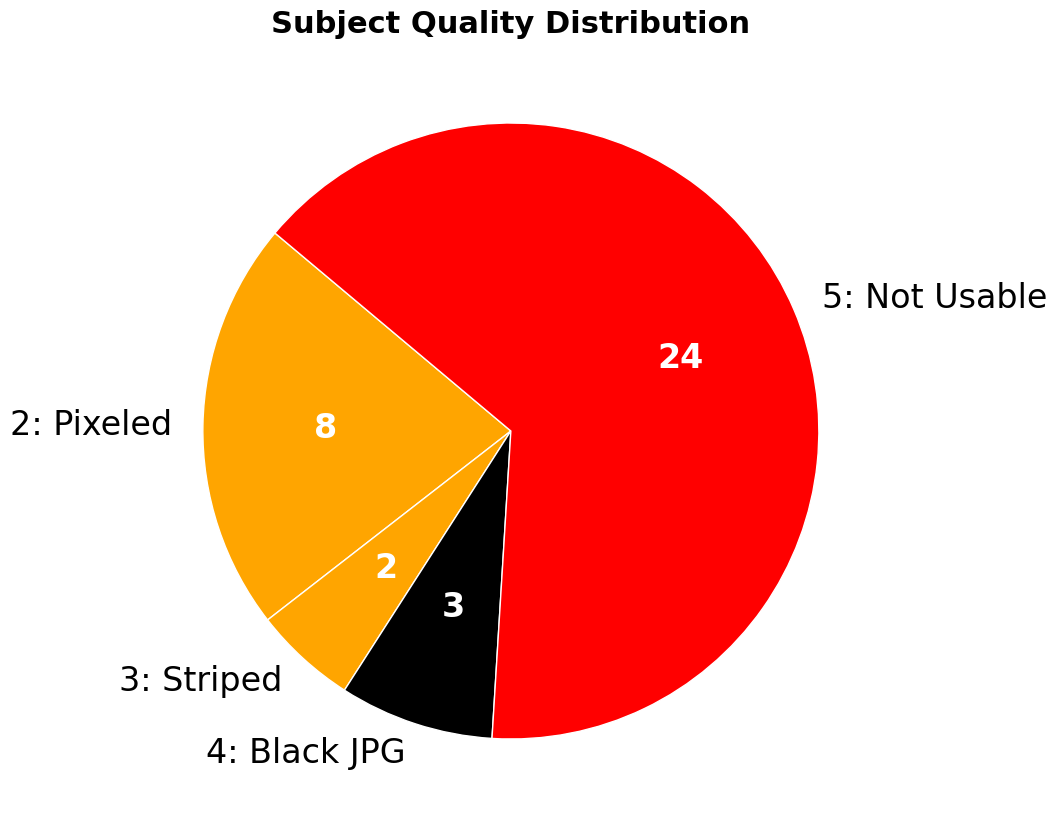

In [24]:
import matplotlib.pyplot as plt

# drop duplicates by subject_id

other_labels_subjects = other_labels_scans.drop_duplicates('subject_id')
# 1. Group the data
other_labels_by_label = other_labels_subjects.groupby('classification_label').size()

# 2. Map the indices to names and colors
mapped_labels = [label_names.get(x, str(x)) for x in other_labels_by_label.index]
pie_colors = [color_map.get(name, 'gray') for name in mapped_labels]

# 3. Define the count formatter
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{v:d}'.format(v=val)
    return my_autopct

# 4. Plot
plt.figure(figsize=(10, 10)) # Increased figure size slightly to accommodate larger text

# Use textprops to set the size of the outer labels
patches, texts, autotexts = plt.pie(
    other_labels_by_label.values, 
    labels=mapped_labels, 
    autopct=make_autopct(other_labels_by_label.values),
    colors=pie_colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 24} # <--- Sets the size for the outer labels
)

# 5. Format the internal numbers (Autotexts)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')
    autotext.set_size(24) # <--- Sets the size for the numbers inside the pie

# 6. Format the Title
plt.title('Subject Quality Distribution', fontsize=22, pad=10, fontweight='bold')

plt.show()

 length of full metadata other labels: 59
amount of pixeled or striped scans: 20


Text(0.5, 1.0, 'Age Distribution of Scans that are Pixeled or Striped')

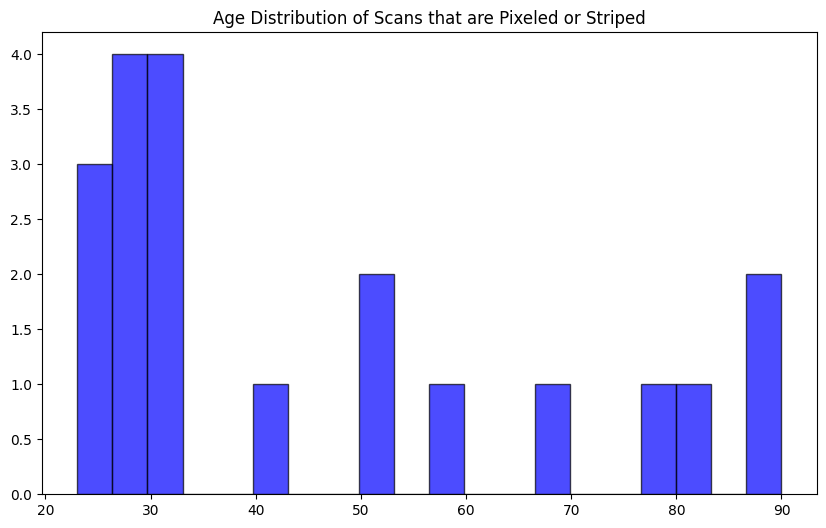

In [32]:
full_metadata_other_labels = combined_df_scans[combined_df_scans['key'].isin(no_good_scans['key'])]
print(f" length of full metadata other labels: {len(full_metadata_other_labels)}")

pixeled_striped_scans = full_metadata_other_labels[full_metadata_other_labels['classification_label'].isin([2, 3])]
print(f"amount of pixeled or striped scans: {len(pixeled_striped_scans)}")

# plot distribution by age_in_years
plt.figure(figsize=(10, 6))
plt.hist(pixeled_striped_scans['age_in_years'], bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title("Age Distribution of Scans that are Pixeled or Striped")